# Alternative Data Test — Using Exact Working Pipeline

**Three clean comparisons:**
1. **FRED-MD only** (baseline) — your existing 52.7% result
2. **FRED-MD + Alternative Data** — does adding our data help?
3. **Alternative Data ONLY** (no FRED-MD) — can our data replace macro?

Uses the **exact same BiGRUClassifier** code from the working classification notebook.
Same scaler, same split, same model, same Optuna params. Only the features change.

In [1]:
!pip install optuna --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 34.3 MB/s eta 0:00:00


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random, pickle, warnings
from abc import ABC, abstractmethod
from pathlib import Path
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, regularizers, Input, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import TimeSeriesSplit
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
random.seed(42); np.random.seed(42); tf.random.set_seed(42)
print('Imports loaded.')

Imports loaded.


In [3]:
from google.colab import drive
drive.mount('/content/drive')
BASE_DIR = Path('/content/drive/MyDrive/Quants ')
ALT_DIR = BASE_DIR / 'alternative_data' / 'raw'

Mounted at /content/drive


## 1. Load Wheat Prices (identical to working notebook)

In [4]:
W18 = BASE_DIR / 'Investing.com' / 'US Wheat Futures Historical Data_2018.csv'
W25 = BASE_DIR / 'Investing.com' / 'US Wheat Futures Historical Data_2025.csv'

def load_price(p):
    df = pd.read_csv(p)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').set_index('Date')
    df['Price'] = df['Price'].astype(str).str.replace(',','',regex=False).astype(float)
    return df['Price']

p1, p2 = load_price(W18), load_price(W25)
df_price = pd.concat([p1, p2.iloc[1:]]).pipe(
    lambda s: s[~s.index.duplicated(keep='last')]).sort_index()
df_price.name = 'Price'
print(f'Wheat prices: {len(df_price)} days')

Wheat prices: 6864 days


## 2. Load FRED-MD (identical to working notebook)

In [5]:
fred_md_path = str(BASE_DIR / 'FredMD_Dataset' / '2025-10-MD.csv')
tcodes_row = pd.read_csv(fred_md_path, nrows=1)
fred_raw = pd.read_csv(fred_md_path, skiprows=[1])
fred_raw['sasdate'] = pd.to_datetime(fred_raw['sasdate'], format='%m/%d/%Y')
fred_raw = fred_raw.set_index('sasdate').sort_index()

features_31 = [
    'RPI','W875RX1','CMRMTSPLx','IPFPNSS','USWTRADE','USTRADE',
    'BUSLOANS','CONSPI','S&P 500','S&P PE ratio','FEDFUNDS','TB3MS',
    'TB6MS','GS1','GS5','GS10','AAA','BAA','TB3SMFFM','TB6SMFFM',
    'T1YFFM','T5YFFM','T10YFFM','AAAFFM','BAAFFM',
    'EXSZUSx','EXJPUSx','EXUSUKx','EXCAUSx','PPICMM','UMCSENTx',
]
tcode_map = {c: int(float(tcodes_row[c].values[0])) for c in features_31}

def apply_tcode(s, tc):
    if tc==1: return s
    if tc==2: return s.diff()
    if tc==3: return s.diff().diff()
    if tc==4: return np.log(s.clip(lower=1e-10))
    if tc==5: return np.log(s.clip(lower=1e-10)).diff()
    if tc==6: return np.log(s.clip(lower=1e-10)).diff().diff()
    if tc==7: return (s/s.shift(1)-1).diff()
    return s

fs = fred_raw[features_31].copy().apply(pd.to_numeric, errors='coerce')
for c in features_31:
    fs[c] = apply_tcode(fs[c], tcode_map[c])
fred_t = fs.dropna().replace([np.inf,-np.inf], np.nan).dropna()
fred_t.index = fred_t.index + pd.DateOffset(months=1)
daily_idx = pd.date_range(fred_t.index.min(), fred_t.index.max()+pd.offsets.MonthEnd(0), freq='D')
df_macro = fred_t.reindex(daily_idx).ffill()
print(f'FRED-MD macro: {df_macro.shape}')

FRED-MD macro: (17351, 31)


## 3. Load Alternative Data Sources

In [6]:
# === TECHNICAL INDICATORS ===
# Need OHLCV for this - load full wheat data
inv_dir = BASE_DIR / 'Investing.com'
all_wheat_files = sorted([f for f in inv_dir.iterdir() if f.suffix=='.csv' and 'Wheat' in f.name])
wdfs = [pd.read_csv(f) for f in all_wheat_files]
wheat_full = pd.concat(wdfs, ignore_index=True)
wheat_full['Date'] = pd.to_datetime(wheat_full['Date'], format='mixed', dayfirst=False)
wheat_full = wheat_full.sort_values('Date').drop_duplicates(subset='Date').set_index('Date')
for c in ['Price','Open','High','Low']:
    wheat_full[c] = pd.to_numeric(wheat_full[c].astype(str).str.replace(',',''), errors='coerce')
def pvol(v):
    v=str(v).strip().replace(',','')
    if v.endswith('K'): return float(v[:-1])*1000
    elif v.endswith('M'): return float(v[:-1])*1e6
    try: return float(v)
    except: return np.nan
wheat_full['Volume'] = wheat_full['Vol.'].apply(pvol)

# Compute tech indicators
c,h,l,v = wheat_full['Price'],wheat_full['High'],wheat_full['Low'],wheat_full['Volume'].fillna(0)
tech = pd.DataFrame(index=wheat_full.index)
for n in [5,10,20]: tech[f'mom_{n}d'] = c.pct_change(n)
d=c.diff(); g=d.clip(lower=0); lo=(-d).clip(lower=0)
tech['rsi']=100-(100/(1+g.rolling(14).mean()/lo.rolling(14).mean().replace(0,np.nan)))
e12,e26=c.ewm(span=12).mean(),c.ewm(span=26).mean()
macd=e12-e26; tech['macd']=macd; tech['macd_hist']=macd-macd.ewm(span=9).mean()
s20,st20=c.rolling(20).mean(),c.rolling(20).std()
tech['bb_pctb']=(c-(s20-2*st20))/(4*st20).replace(0,np.nan)
tr=pd.concat([h-l,(h-c.shift(1)).abs(),(l-c.shift(1)).abs()],axis=1).max(axis=1)
tech['atr']=tr.rolling(14).mean()
tech['vol_sma']=v/v.rolling(20).mean().replace(0,np.nan)
tech_cols = tech.columns.tolist()
print(f'Tech indicators: {tech_cols}')

Tech indicators: ['mom_5d', 'mom_10d', 'mom_20d', 'rsi', 'macd', 'macd_hist', 'bb_pctb', 'atr', 'vol_sma']


In [7]:
# === COT ===
cot_raw = pd.read_csv(ALT_DIR / 'cot_wheat_disaggregated.csv')
cot_raw['Date'] = pd.to_datetime(cot_raw['Report_Date_as_YYYY-MM-DD'])
nc=['Open_Interest_All','Prod_Merc_Positions_Long_All','Prod_Merc_Positions_Short_All',
    'M_Money_Positions_Long_All','M_Money_Positions_Short_All']
for c in nc: cot_raw[c]=pd.to_numeric(cot_raw[c],errors='coerce')
cot=cot_raw.groupby('Date')[nc].sum().reset_index()
oi=cot['Open_Interest_All'].replace(0,np.nan)
cot['mm_net']=cot['M_Money_Positions_Long_All']-cot['M_Money_Positions_Short_All']
cot['cm_net']=cot['Prod_Merc_Positions_Long_All']-cot['Prod_Merc_Positions_Short_All']
cot['hedge_pr']=cot['cm_net']/oi; cot['spec_se']=cot['mm_net']/oi
cot['pos_chg']=cot['mm_net'].diff(4)
cot['spec_z']=(cot['mm_net']-cot['mm_net'].rolling(52).mean())/cot['mm_net'].rolling(52).std().replace(0,np.nan)
cot['oi_lev']=cot['Open_Interest_All']
cot_features=['hedge_pr','spec_se','pos_chg','spec_z','oi_lev']
cot['Date']=cot['Date']+pd.Timedelta(days=3)
cot_daily=cot.set_index('Date')[cot_features].resample('D').ffill()
print(f'COT: {len(cot_daily)} rows')

COT: 4740 rows


In [8]:
# === CROSS-COMMODITY ===
ca={'corn_futures.csv':'corn','soybean_futures.csv':'soy','crude_oil_wti.csv':'oil',
    'usd_index.csv':'usd','gold_futures.csv':'gold'}
cdfs=[]
for fn,lb in ca.items():
    d=pd.read_csv(ALT_DIR/fn,header=[0,1],index_col=0,parse_dates=True)
    d.columns=[c[0] for c in d.columns]; d=d.reset_index()
    d['Date']=pd.to_datetime(d['Date']); d[f'{lb}_cl']=pd.to_numeric(d['Close'],errors='coerce')
    cdfs.append(d[['Date',f'{lb}_cl']].dropna().set_index('Date'))
xc=cdfs[0]
for d in cdfs[1:]: xc=xc.join(d,how='outer')
xc=xc.sort_index().ffill().dropna()
# Add wheat price for ratios
xc=xc.join(df_price, how='inner')
xc['wc_rat']=xc['Price']/xc['corn_cl'].replace(0,np.nan)
xc['ws_rat']=xc['Price']/xc['soy_cl'].replace(0,np.nan)
xc['wc_m20']=xc['wc_rat'].pct_change(20); xc['ws_m20']=xc['ws_rat'].pct_change(20)
wr=xc['Price'].pct_change(10)
xc['rel_cn']=wr-xc['corn_cl'].pct_change(10)
xc['rel_ol']=wr-xc['oil_cl'].pct_change(10)
xc['usd_c10']=xc['usd_cl'].pct_change(10)
xc['gld_c10']=xc['gold_cl'].pct_change(10)
cross_fcols=['wc_rat','ws_rat','wc_m20','ws_m20','rel_cn','rel_ol','usd_c10','gld_c10']
cross_daily = xc[cross_fcols]
print(f'Cross: {len(cross_daily)} rows, {cross_fcols}')

Cross: 4514 rows, ['wc_rat', 'ws_rat', 'wc_m20', 'ws_m20', 'rel_cn', 'rel_ol', 'usd_c10', 'gld_c10']


In [9]:
# === GOOGLE TRENDS + WEATHER + VIX/OVX + NASA ===
gt=pd.read_csv(ALT_DIR/'google_trends.csv',parse_dates=['Date'],index_col='Date')
gt_cols=[c for c in gt.columns if c!='isPartial']
gt=gt[gt_cols].resample('D').ffill()
print(f'Trends: {len(gt)} rows')

wk=pd.read_csv(ALT_DIR/'weather_kansas.csv',parse_dates=['Date'],index_col='Date')
wnd=pd.read_csv(ALT_DIR/'weather_north_dakota.csv',parse_dates=['Date'],index_col='Date')
weather=wk.join(wnd,how='outer',lsuffix='',rsuffix='').sort_index().ffill().dropna()
weather_cols=weather.columns.tolist()
print(f'Weather: {len(weather)} rows, {len(weather_cols)} features')

vix=pd.read_csv(ALT_DIR/'vix.csv',parse_dates=['Date'],index_col='Date')
ovx=pd.read_csv(ALT_DIR/'ovx.csv',parse_dates=['Date'],index_col='Date')
fear=vix.join(ovx,how='outer').sort_index().ffill().dropna()
fear_cols=fear.columns.tolist()
print(f'VIX/OVX: {len(fear)} rows')

nasa=pd.read_csv(ALT_DIR/'nasa_power_ag.csv',parse_dates=['Date'],index_col='Date').dropna()
nasa_cols=nasa.columns.tolist()
print(f'NASA: {len(nasa)} rows')

Trends: 5814 rows
Weather: 5844 rows, 12 features
VIX/OVX: 4528 rows
NASA: 5844 rows


## 4. Build Three Feature DataFrames

In [10]:
# Combine all alternative data into one daily dataframe
alt_data = tech.copy()
for df in [cot_daily, cross_daily, gt, weather, fear, nasa]:
    alt_data = alt_data.join(df, how='outer')
alt_data = alt_data.sort_index().ffill().bfill()
alt_data = alt_data.replace([np.inf,-np.inf], np.nan).ffill().bfill()
alt_cols = alt_data.columns.tolist()
print(f'All alternative features: {len(alt_cols)} columns')
print(f'Date range: {alt_data.index.min().date()} to {alt_data.index.max().date()}')

All alternative features: 48 columns
Date range: 1999-08-01 to 2026-01-02


In [11]:
# === THREE DATASETS (all indexed by date, joined with wheat price) ===

# 1. BASELINE: FRED-MD only (matches your existing notebook)
df_baseline = df_macro.join(df_price, how='inner').loc['2008-01-01':]
cols_bl = [c for c in df_baseline.columns if c!='Price'] + ['Price']
df_baseline = df_baseline[cols_bl]
print(f'Baseline (FRED-MD + Price): {df_baseline.shape}')

# 2. FRED-MD + ALTERNATIVE DATA
df_combined = df_macro.join(alt_data, how='outer').ffill().bfill()
df_combined = df_combined.join(df_price, how='inner').loc['2008-01-01':]
# Put Price last
cols_cb = [c for c in df_combined.columns if c!='Price'] + ['Price']
df_combined = df_combined[cols_cb].replace([np.inf,-np.inf],np.nan).ffill().bfill().dropna()
print(f'FRED-MD + Alt (combined): {df_combined.shape}')

# 3. ALTERNATIVE DATA ONLY (no FRED-MD)
df_altonly = alt_data.join(df_price, how='inner').loc['2008-01-01':]
cols_ao = [c for c in df_altonly.columns if c!='Price'] + ['Price']
df_altonly = df_altonly[cols_ao].replace([np.inf,-np.inf],np.nan).ffill().bfill().dropna()
print(f'Alt only (no FRED-MD): {df_altonly.shape}')

Baseline (FRED-MD + Price): (4635, 32)
FRED-MD + Alt (combined): (4710, 80)
Alt only (no FRED-MD): (4710, 49)


## 5. Create Windows (identical to working notebook)

In [12]:
LB = 30

def make_dataset(df):
    """Create X, y arrays exactly like the working notebook."""
    pidx = df.columns.get_loc('Price')
    data = df.values
    X, y = [], []
    for i in range(LB, len(data)):
        X.append(data[i-LB:i])
        y.append(1 if data[i, pidx] > data[i-1, pidx] else 0)
    X, y = np.array(X), np.array(y)
    sp = int(len(X) * 0.8)
    return X[:sp], y[:sp], X[sp:], y[sp:]

Xtr_bl, ytr_bl, Xte_bl, yte_bl = make_dataset(df_baseline)
Xtr_cb, ytr_cb, Xte_cb, yte_cb = make_dataset(df_combined)
Xtr_ao, ytr_ao, Xte_ao, yte_ao = make_dataset(df_altonly)

print(f'Baseline:  Train={Xtr_bl.shape} Test={Xte_bl.shape} ({df_baseline.shape[1]} features)')
print(f'Combined:  Train={Xtr_cb.shape} Test={Xte_cb.shape} ({df_combined.shape[1]} features)')
print(f'Alt-only:  Train={Xtr_ao.shape} Test={Xte_ao.shape} ({df_altonly.shape[1]} features)')

Baseline:  Train=(3684, 30, 32) Test=(921, 30, 32) (32 features)
Combined:  Train=(3744, 30, 80) Test=(936, 30, 80) (80 features)
Alt-only:  Train=(3744, 30, 49) Test=(936, 30, 49) (49 features)


## 6. BiGRU Classifier (identical to working notebook)

In [13]:
class BiGRUClassifier:
    def __init__(self, hidden_size=64, num_layers=2, weight_decay=0.02,
                 dropout=0.2, early_stop_patience=10, epochs=100,
                 batch_size=64, learning_rate=1e-3):
        self.hidden_size=hidden_size; self.num_layers=num_layers
        self.weight_decay=weight_decay; self.dropout=dropout
        self.early_stop_patience=early_stop_patience
        self.epochs=epochs; self.batch_size=batch_size
        self.learning_rate=learning_rate
        self.model=None; self.x_scaler=None

    def _build_model(self, seq_length, feature_dim):
        inputs = Input(shape=(seq_length, feature_dim))
        h = layers.Bidirectional(layers.GRU(
            units=self.hidden_size, dropout=self.dropout,
            kernel_regularizer=regularizers.l2(self.weight_decay),
            return_sequences=True))(inputs)
        for _ in range(self.num_layers - 1):
            h = layers.Bidirectional(layers.GRU(
                units=self.hidden_size, dropout=self.dropout,
                kernel_regularizer=regularizers.l2(self.weight_decay),
                return_sequences=True))(h)
        x = layers.GlobalAveragePooling1D()(h)
        x = layers.Dropout(self.dropout)(x)
        outputs = layers.Dense(1, activation='sigmoid',
                               kernel_regularizer=regularizers.l2(self.weight_decay))(x)
        return Model(inputs=inputs, outputs=outputs)

    def _scale_X(self, X, fit=False):
        n, lb, nf = X.shape
        flat = X.reshape(n, lb*nf)
        if fit:
            self.x_scaler = StandardScaler()
            flat = self.x_scaler.fit_transform(flat)
        else:
            flat = self.x_scaler.transform(flat)
        return flat.reshape(n, lb, nf)

    def fit(self, X_train, y_train):
        Xs = self._scale_X(X_train, fit=True)
        cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
        self.model = self._build_model(X_train.shape[1], X_train.shape[2])
        self.model.compile(optimizer=Adam(learning_rate=self.learning_rate),
                           loss='binary_crossentropy', metrics=['accuracy'])
        self.model.fit(Xs, y_train, epochs=self.epochs, batch_size=self.batch_size,
                       shuffle=False, class_weight={0:cw[0],1:cw[1]}, verbose=0,
                       callbacks=[
                           EarlyStopping(monitor='loss', patience=self.early_stop_patience,
                                         restore_best_weights=True),
                           ReduceLROnPlateau(monitor='loss', factor=0.5, patience=5, min_lr=1e-6)])
        p = (self.model.predict(Xs, verbose=0).ravel()>=0.5).astype(int)
        print(f'  Train Acc: {accuracy_score(y_train,p):.4f} F1: {f1_score(y_train,p,zero_division=0):.4f}')

    def predict(self, X):
        return self.model.predict(self._scale_X(X), verbose=0).ravel()

    def evaluate(self, X, y):
        pr = self.predict(X); pd_ = (pr>=0.5).astype(int)
        return {'accuracy': accuracy_score(y,pd_),
                'precision': precision_score(y,pd_,zero_division=0),
                'recall': recall_score(y,pd_,zero_division=0),
                'f1': f1_score(y,pd_,zero_division=0),
                'auc_roc': roc_auc_score(y,pr)}

print('BiGRUClassifier defined (identical to working notebook).')

BiGRUClassifier defined (identical to working notebook).


## 7. Run Three Experiments

Using Optuna-found hyperparameters from the working notebook.

In [14]:
# Optuna best params from working BiGRU classification notebook
BEST_PARAMS = dict(
    learning_rate=2.8166e-4,
    hidden_size=128,
    num_layers=3,
    weight_decay=1.8059e-5,
    dropout=0.371,
    early_stop_patience=10,
    epochs=50,
    batch_size=64,
)

experiments = {
    'A. FRED-MD only (baseline)': (Xtr_bl, ytr_bl, Xte_bl, yte_bl),
    'B. FRED-MD + Alt Data':      (Xtr_cb, ytr_cb, Xte_cb, yte_cb),
    'C. Alt Data only (no FRED)': (Xtr_ao, ytr_ao, Xte_ao, yte_ao),
}

results = []
all_preds = {}

for name, (Xtr, ytr, Xte, yte) in experiments.items():
    print(f'\n{"="*60}')
    print(f'  {name}')
    print(f'  Features: {Xtr.shape[2]}, Train: {Xtr.shape[0]}, Test: {Xte.shape[0]}')
    print(f'{"="*60}')

    random.seed(42); np.random.seed(42); tf.random.set_seed(42)
    model = BiGRUClassifier(**BEST_PARAMS)
    model.fit(Xtr, ytr)

    probs = model.predict(Xte)
    preds = (probs >= 0.5).astype(int)

    m = model.evaluate(Xte, yte)
    m['Experiment'] = name
    m['Features'] = Xtr.shape[2]
    results.append(m)
    all_preds[name] = {'y_test': yte, 'y_pred': preds, 'y_prob': probs}

    print(f'\n  Test Results:')
    print(f'  Accuracy:  {m["accuracy"]:.4f}')
    print(f'  Precision: {m["precision"]:.4f}')
    print(f'  Recall:    {m["recall"]:.4f}')
    print(f'  F1:        {m["f1"]:.4f}')
    print(f'  AUC-ROC:   {m["auc_roc"]:.4f}')
    print(f'  Pred >0.5: {(probs>0.5).sum()}/{len(probs)}  <0.5: {(probs<0.5).sum()}/{len(probs)}')
    print(f'\n{classification_report(yte, preds, target_names=["Down","Up"])}')

print('\nAll experiments complete!')


  A. FRED-MD only (baseline)
  Features: 32, Train: 3684, Test: 921
  Train Acc: 0.5217 F1: 0.4667

  Test Results:
  Accuracy:  0.5255
  Precision: 0.4884
  Recall:    0.6439
  F1:        0.5554
  AUC-ROC:   0.5379
  Pred >0.5: 559/921  <0.5: 362/921

              precision    recall  f1-score   support

        Down       0.58      0.42      0.49       497
          Up       0.49      0.64      0.56       424

    accuracy                           0.53       921
   macro avg       0.54      0.53      0.52       921
weighted avg       0.54      0.53      0.52       921


  B. FRED-MD + Alt Data
  Features: 80, Train: 3744, Test: 936
  Train Acc: 0.5636 F1: 0.5443

  Test Results:
  Accuracy:  0.4776
  Precision: 0.4612
  Recall:    0.9267
  F1:        0.6159
  AUC-ROC:   0.5094
  Pred >0.5: 850/936  <0.5: 86/936

              precision    recall  f1-score   support

        Down       0.64      0.11      0.18       513
          Up       0.46      0.93      0.62       423

    acc

## 8. Results Comparison

In [15]:
rdf = pd.DataFrame(results).set_index('Experiment')
print('='*70)
print('RESULTS — Does Alternative Data Help?')
print('='*70)
print(rdf[['Features','accuracy','precision','recall','f1','auc_roc']].to_string(float_format='{:.4f}'.format))
print()
print(f'Baseline (FRED-MD):    Acc={rdf.loc["A. FRED-MD only (baseline)","accuracy"]:.4f}  AUC={rdf.loc["A. FRED-MD only (baseline)","auc_roc"]:.4f}')
print(f'Combined (FRED+Alt):   Acc={rdf.loc["B. FRED-MD + Alt Data","accuracy"]:.4f}  AUC={rdf.loc["B. FRED-MD + Alt Data","auc_roc"]:.4f}')
print(f'Alt-only (no FRED):    Acc={rdf.loc["C. Alt Data only (no FRED)","accuracy"]:.4f}  AUC={rdf.loc["C. Alt Data only (no FRED)","auc_roc"]:.4f}')

RESULTS — Does Alternative Data Help?
                            Features  accuracy  precision  recall     f1  auc_roc
Experiment                                                                       
A. FRED-MD only (baseline)        32    0.5255     0.4884  0.6439 0.5554   0.5379
B. FRED-MD + Alt Data             80    0.4776     0.4612  0.9267 0.6159   0.5094
C. Alt Data only (no FRED)        49    0.4765     0.4593  0.8936 0.6067   0.5331

Baseline (FRED-MD):    Acc=0.5255  AUC=0.5379
Combined (FRED+Alt):   Acc=0.4776  AUC=0.5094
Alt-only (no FRED):    Acc=0.4765  AUC=0.5331


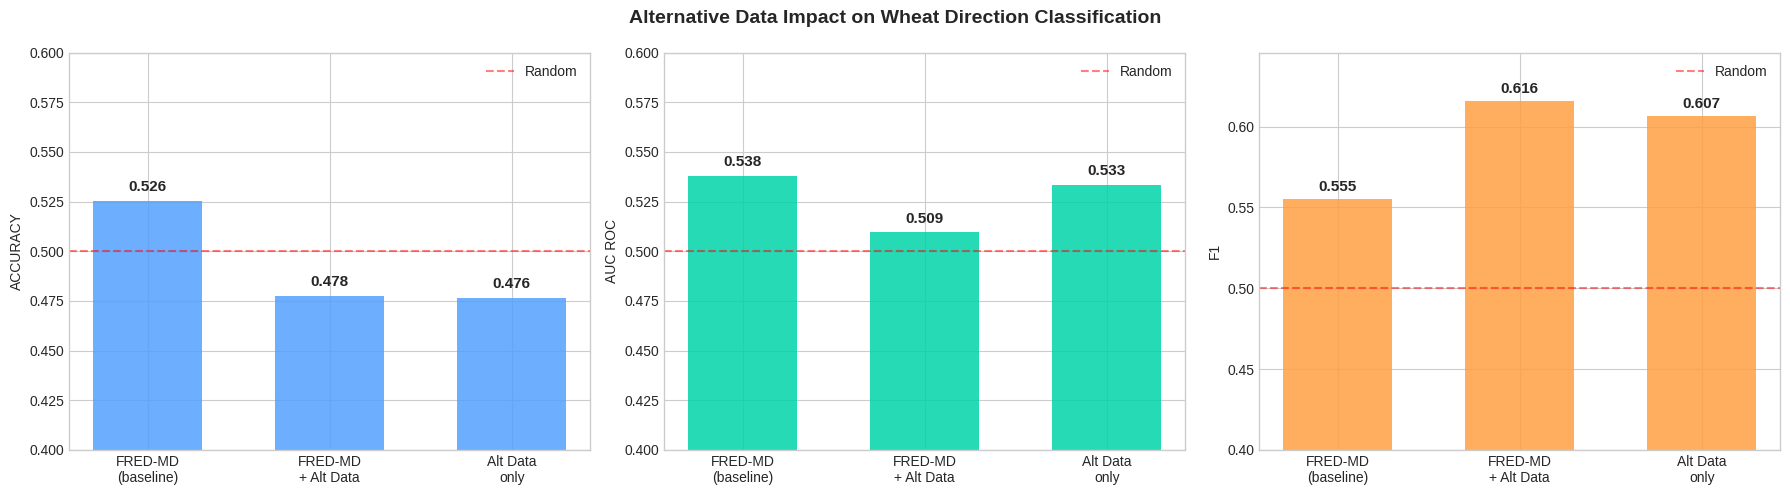

In [16]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, color in zip(axes, ['accuracy','auc_roc','f1'], ['#54A0FF','#00D4AA','#FF9F43']):
    vals = rdf[metric]
    bars = ax.bar(range(len(vals)), vals.values, color=color, alpha=0.85, width=0.6)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(['FRED-MD\n(baseline)', 'FRED-MD\n+ Alt Data', 'Alt Data\nonly'], fontsize=10)
    ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random')
    ax.set_ylabel(metric.replace('_',' ').upper()); ax.legend()
    ax.set_ylim(0.40, max(0.60, vals.max()+0.03))
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.005, f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
fig.suptitle('Alternative Data Impact on Wheat Direction Classification', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

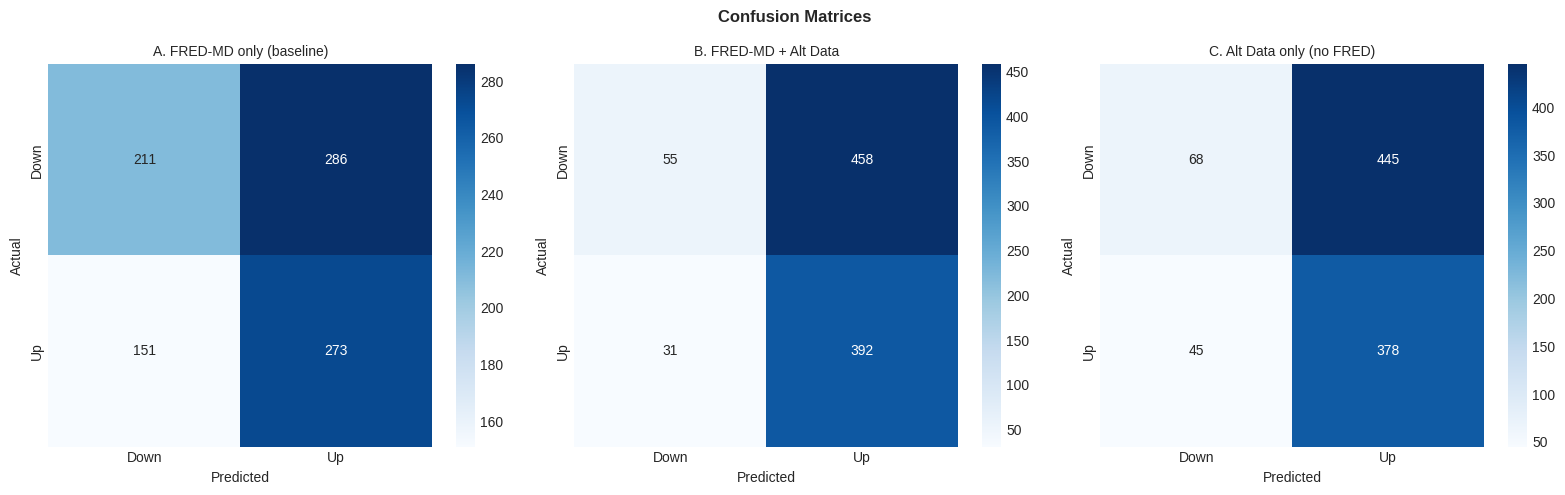

In [17]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, name in zip(axes, experiments.keys()):
    p = all_preds[name]
    cm = confusion_matrix(p['y_test'], p['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Down','Up'], yticklabels=['Down','Up'])
    ax.set_title(name, fontsize=10); ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.suptitle('Confusion Matrices', fontweight='bold')
plt.tight_layout(); plt.show()

In [18]:
# Save
out = str(BASE_DIR / 'alternative_data' / 'processed' / 'v4_comparison_results.csv')
import os; os.makedirs(os.path.dirname(out), exist_ok=True)
rdf.to_csv(out)
print(f'Saved: {out}')

Saved: /content/drive/MyDrive/Quants /alternative_data/processed/v4_comparison_results.csv
